In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt 

In [9]:
df = pd.read_csv("heart_disease_uci.csv")

In [11]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [14]:
missing_values = df.isnull().sum()
print(missing_values)

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [18]:
df = df.drop(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'] , axis= 1)

In [19]:
df.head()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
0,1,63,145.0,233.0,150.0,2.3,0.0,0
1,2,67,160.0,286.0,108.0,1.5,3.0,2
2,3,67,120.0,229.0,129.0,2.6,2.0,1
3,4,37,130.0,250.0,187.0,3.5,0.0,0
4,5,41,130.0,204.0,172.0,1.4,0.0,0


In [20]:
missing_values =df.isnull().sum()
print(missing_values)

id            0
age           0
trestbps     59
chol         30
thalch       55
oldpeak      62
ca          611
num           0
dtype: int64


In [22]:
df.shape

(920, 8)

In [26]:
df_cleaned = df.dropna()

In [28]:
df_cleaned.shape

(308, 8)

In [30]:
missing_values =df_cleaned.isnull().sum()
print(missing_values)

id          0
age         0
trestbps    0
chol        0
thalch      0
oldpeak     0
ca          0
num         0
dtype: int64


In [32]:
x = df_cleaned.drop('num', axis=1)
y = df_cleaned['num']

In [33]:
x_train , x_test , y_train , y_test = train_test_split(x, y, test_size = 0.2 , random_state= 42)

In [34]:
x_train

,id,age,trestbps,chol,thalch,oldpeak,ca
126,127,56,200.0,288.0,133.0,4.0,2.0
109,110,39,118.0,219.0,140.0,1.2,0.0
249,250,62,128.0,208.0,140.0,0.0,0.0
236,237,56,130.0,283.0,103.0,1.6,0.0
204,205,43,110.0,211.0,161.0,0.0,0.0
...,...,...,...,...,...,...,...
189,190,69,140.0,254.0,146.0,2.0,3.0
71,72,67,125.0,254.0,163.0,0.2,2.0
106,107,59,140.0,177.0,162.0,0.0,1.0
272,273,46,140.0,311.0,120.0,1.8,2.0


In [36]:
x_test

,id,age,trestbps,chol,thalch,oldpeak,ca
291,292,55,132.0,342.0,166.0,1.2,0.0
9,10,53,140.0,203.0,155.0,3.1,0.0
57,58,41,110.0,172.0,158.0,0.0,0.0
60,61,51,130.0,305.0,142.0,1.2,0.0
25,26,50,120.0,219.0,158.0,1.6,0.0
...,...,...,...,...,...,...,...
200,201,50,110.0,254.0,159.0,0.0,0.0
197,198,45,138.0,236.0,152.0,0.2,0.0
212,213,41,130.0,214.0,168.0,2.0,0.0
226,227,47,112.0,204.0,143.0,0.1,0.0


In [38]:
clf_model = RandomForestClassifier()
clf_model.fit( x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
y_pred = clf_model.predict( x_test)

In [42]:
y_pred

array([0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 3, 2, 1, 0, 3, 3, 0, 0, 3,
       1, 0, 2, 1, 2, 0, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 0, 3, 0, 1, 0, 0,
       2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 3, 3, 1, 0, 0, 0, 0, 1])

In [43]:
y_test

291    0
9      1
57     1
60     2
25     0
      ..
200    0
197    0
212    0
226    0
158    2
Name: num, Length: 62, dtype: int64

In [49]:
cm = confusion_matrix( y_test, y_pred)


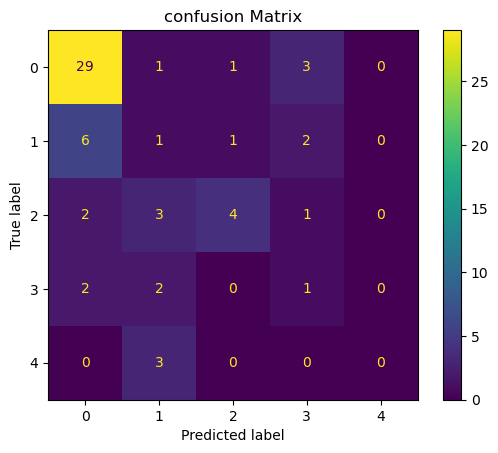

In [51]:
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.title("confusion Matrix")
plt.show()

In [53]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.74      0.85      0.79        34
           1       0.10      0.10      0.10        10
           2       0.67      0.40      0.50        10
           3       0.14      0.20      0.17         5
           4       0.00      0.00      0.00         3

    accuracy                           0.56        62
   macro avg       0.33      0.31      0.31        62
weighted avg       0.54      0.56      0.55        62



C:\Users\pc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
